# MobileNetV2 transfer learning on CIFAR-10

**Author:** [Kiana Pilevar Abrisham](https://github.com/KianaAbrisham)

A complete experiment with a frozen ImageNet backbone, training-only
augmentation, validation-based checkpoint selection, held-out evaluation,
error inspection, and inference from a saved model.

Images remain at their native **32 × 32** resolution in the dataset.
Resizing and normalization happen inside the model, one batch at a time,
and are retained in the saved checkpoint.

The default quick run uses **2,000 training, 500 validation, and 1,000 test
images** for **three epochs**. The recorded outputs demonstrate a small
real-data experiment; they are not a full CIFAR-10 benchmark.

Install `requirements.txt`, select that environment as the notebook kernel,
and use **Restart Kernel and Run All**. The first run downloads CIFAR-10
(about 170 MB) and ImageNet weights (about 9.4 MB). Each execution creates
a new output directory.

## 1. Configure the experiment

Set `MODE = "full"` before execution to use all 40,000/10,000/10,000
train/validation/test images with up to 15 epochs. Full mode takes more
CPU time and is not the source of the recorded quick-run results.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json
import os
import platform
import time
import uuid

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
import keras
from keras import layers
from IPython import get_ipython
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score,
)

get_ipython().run_line_magic("matplotlib", "inline")
SEED = 42
MODE = "quick"
IMAGE_SIZE = 224
BATCH_SIZE = 16
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = len(CLASS_NAMES)
if MODE not in {"quick", "full"}:
    raise ValueError('MODE must be "quick" or "full".')
EPOCHS = 3 if MODE == "quick" else 15

tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.experimental.enable_op_determinism()
keras.utils.set_random_seed(SEED)

working_directory = Path.cwd()
ROOT = working_directory.parent if working_directory.name == "notebooks" else working_directory
run_name = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "-" + uuid.uuid4().hex[:8]
RUN_DIR = ROOT / "runs" / run_name
RUN_DIR.mkdir(parents=True, exist_ok=False)
start_time = time.perf_counter()
environment = {
    "python": platform.python_version(), "platform": platform.platform(),
    "tensorflow": tf.__version__, "keras": keras.__version__,
    "numpy": np.__version__, "scikit_learn": sklearn.__version__,
    "visible_devices": [device.device_type for device in tf.config.list_physical_devices()],
}
print(json.dumps(environment, indent=2))
print(f"Mode: {MODE}; epochs: {EPOCHS}; batch size: {BATCH_SIZE}")
print("Run directory:", RUN_DIR.relative_to(ROOT))

No event loop hook running.
{
  "python": "3.12.14",
  "platform": "Linux-6.18.44-x86_64-with-glibc2.39",
  "tensorflow": "2.20.0",
  "keras": "3.11.3",
  "numpy": "2.3.5",
  "scikit_learn": "1.8.0",
  "visible_devices": [
    "CPU"
  ]
}
Mode: quick; epochs: 3; batch size: 16
Run directory: runs/20260927T143525Z-17d288eb


## 2. Reserve validation and test data

Validation images come only from CIFAR-10's official training split. The
official test split stays separate. Quick mode selects seeded, stratified
subsets of these partitions. The saved indices identify every selected row.

In [2]:
(all_train_images, all_train_labels), (all_test_images, all_test_labels) = keras.datasets.cifar10.load_data()
all_train_labels = all_train_labels.reshape(-1)
all_test_labels = all_test_labels.reshape(-1)
train_indices, validation_indices = train_test_split(
    np.arange(len(all_train_labels)), test_size=0.2,
    stratify=all_train_labels, random_state=SEED,
)
test_indices = np.arange(len(all_test_labels))

def stratified_subset(indices, labels, size):
    """Select a repeatable subset while preserving class proportions."""
    if size >= len(indices):
        return indices.copy()
    selected, _ = train_test_split(
        indices, train_size=size, stratify=labels[indices], random_state=SEED,
    )
    return selected

if MODE == "quick":
    train_indices = stratified_subset(train_indices, all_train_labels, 2000)
    validation_indices = stratified_subset(validation_indices, all_train_labels, 500)
    test_indices = stratified_subset(test_indices, all_test_labels, 1000)

assert not np.intersect1d(train_indices, validation_indices).size
x_train, y_train = all_train_images[train_indices], all_train_labels[train_indices]
x_validation = all_train_images[validation_indices]
y_validation = all_train_labels[validation_indices]
x_test, y_test = all_test_images[test_indices], all_test_labels[test_indices]
del all_train_images, all_test_images

np.savez_compressed(
    RUN_DIR / "split_indices.npz", official_train_training=train_indices,
    official_train_validation=validation_indices, official_test=test_indices,
)
split_digest = hashlib.sha256((RUN_DIR / "split_indices.npz").read_bytes()).hexdigest()
for name, images, labels in [
    ("Training", x_train, y_train),
    ("Validation", x_validation, y_validation),
    ("Test", x_test, y_test),
]:
    print(f"{name}: {images.shape}, {images.dtype}, class counts {np.bincount(labels, minlength=NUM_CLASSES)}")

Training: (2000, 32, 32, 3), uint8, class counts [200 200 200 200 200 200 200 200 200 200]
Validation: (500, 32, 32, 3), uint8, class counts [50 50 50 50 50 50 50 50 50 50]
Test: (1000, 32, 32, 3), uint8, class counts [100 100 100 100 100 100 100 100 100 100]


## 3. Batch before resizing

The dataset shuffles native images, batches them, and prefetches one batch.
It never creates an array of the complete dataset at 224 × 224 resolution.

In [3]:
def make_dataset(images, labels, training=False):
    """Keep storage and shuffle buffers at native CIFAR-10 resolution."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        dataset = dataset.shuffle(
            min(len(images), 2048), seed=SEED, reshuffle_each_iteration=True,
        )
    options = tf.data.Options()
    options.deterministic = True
    options.threading.private_threadpool_size = 1
    options.threading.max_intra_op_parallelism = 1
    return dataset.batch(BATCH_SIZE).with_options(options).prefetch(1)

train_dataset = make_dataset(x_train, y_train, training=True)
validation_dataset = make_dataset(x_validation, y_validation)
test_dataset = make_dataset(x_test, y_test)
example_batch, _ = next(iter(validation_dataset))
assert example_batch.shape[1:] == (32, 32, 3)
print("Dataset batch:", example_batch.shape, example_batch.dtype)
resized_batch_mb = BATCH_SIZE * IMAGE_SIZE * IMAGE_SIZE * 3 * 4 / 1e6
print(f"One resized float32 batch: {resized_batch_mb:.2f} MB (excluding model/intermediate memory)")

Dataset batch: (16, 32, 32, 3) <dtype: 'uint8'>
One resized float32 batch: 9.63 MB (excluding model/intermediate memory)


## 4. Build the transfer-learning model

MobileNetV2 starts from ImageNet weights. Its backbone remains frozen, with
batch normalization in inference mode. Only the classification head is
trained; random augmentation is active during training only.

The model accepts RGB pixels in **[0, 255]** and saves its resizing and
transformation to **[-1, 1]**. Do not normalize images separately at inference.

In [4]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED + 1),
    layers.RandomZoom(0.1, seed=SEED + 2),
], name="training_augmentation")
backbone = keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights="imagenet",
)
backbone.trainable = False

inputs = keras.Input(shape=(None, None, 3), dtype="float32", name="rgb_pixels")
features = layers.Resizing(IMAGE_SIZE, IMAGE_SIZE, interpolation="bilinear", name="resize")(inputs)
features = augmentation(features)
features = layers.Rescaling(1.0 / 127.5, offset=-1, name="mobilenet_normalization")(features)
features = backbone(features, training=False)
features = layers.GlobalAveragePooling2D(name="global_average_pool")(features)
features = layers.Dropout(0.2, seed=SEED + 3)(features)
probabilities = layers.Dense(NUM_CLASSES, activation="softmax", name="class_probabilities")(features)
model = keras.Model(inputs, probabilities, name="cifar10_mobilenetv2")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"],
)
trainable_parameters = sum(int(np.prod(weight.shape)) for weight in model.trainable_weights)
print("Backbone: ImageNet MobileNetV2, frozen")
print(f"Total parameters: {model.count_params():,}; trainable: {trainable_parameters:,}")
print("Saved model input:", model.input_shape, "raw RGB pixels in [0, 255]")

Backbone: ImageNet MobileNetV2, frozen
Total parameters: 2,270,794; trainable: 12,810
Saved model input: (None, None, None, 3) raw RGB pixels in [0, 255]


## 5. Train and select the checkpoint with validation loss

The test dataset is not passed to training. Validation loss selects the
checkpoint and controls early stopping, before any test results are inspected.

In [5]:
CHECKPOINT = RUN_DIR / "best.keras"
training_start = time.perf_counter()
history = model.fit(
    train_dataset, validation_data=validation_dataset, epochs=EPOCHS, verbose=2,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            CHECKPOINT, monitor="val_loss", mode="min", save_best_only=True,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=4, restore_best_weights=True,
        ),
        keras.callbacks.CSVLogger(RUN_DIR / "history.csv"),
        keras.callbacks.TerminateOnNaN(),
    ],
)
training_seconds = time.perf_counter() - training_start
if not all(np.isfinite(values).all() for values in history.history.values()):
    raise RuntimeError("Training produced nonfinite metrics.")
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
model = keras.models.load_model(CHECKPOINT, compile=False, safe_mode=True)
print(f"Loaded validation-selected checkpoint from epoch {best_epoch}.")
print(f"Training duration: {training_seconds:.1f} seconds")

Epoch 1/3
125/125 - 43s - 344ms/step - accuracy: 0.4895 - loss: 1.5601 - val_accuracy: 0.6840 - val_loss: 0.8241
Epoch 2/3
125/125 - 49s - 393ms/step - accuracy: 0.7225 - loss: 0.8527 - val_accuracy: 0.7380 - val_loss: 0.7279
Epoch 3/3
125/125 - 49s - 392ms/step - accuracy: 0.7615 - loss: 0.7172 - val_accuracy: 0.7940 - val_loss: 0.6208
Loaded validation-selected checkpoint from epoch 3.
Training duration: 141.1 seconds


## 6. Inspect training and validation curves

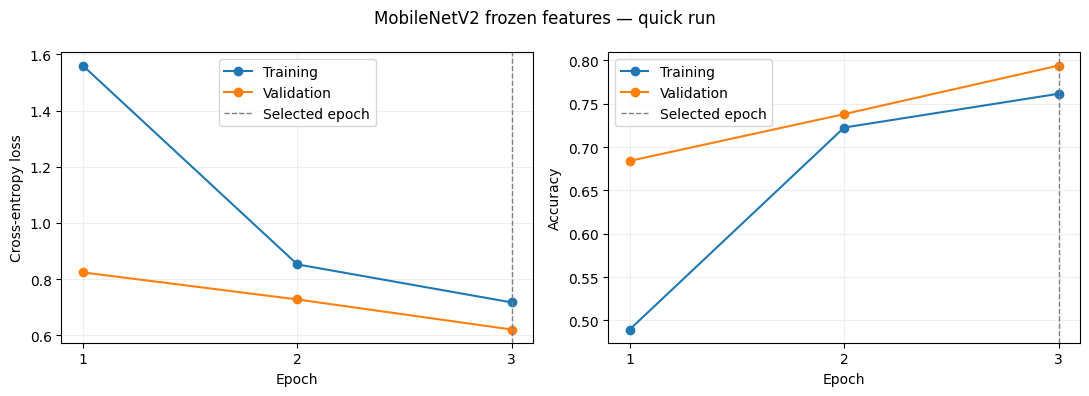

In [6]:
epoch_numbers = np.arange(1, len(history.history["loss"]) + 1)
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, metric, label in zip(axes, ["loss", "accuracy"], ["Cross-entropy loss", "Accuracy"]):
    axis.plot(epoch_numbers, history.history[metric], marker="o", label="Training")
    axis.plot(epoch_numbers, history.history["val_" + metric], marker="o", label="Validation")
    axis.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label="Selected epoch")
    axis.set(xlabel="Epoch", ylabel=label, xticks=epoch_numbers)
    axis.legend()
    axis.grid(alpha=0.2)
figure.suptitle(f"MobileNetV2 frozen features — {MODE} run")
figure.tight_layout()
figure.savefig(RUN_DIR / "training_curves.png", dpi=140)
plt.show()

## 7. Evaluate the selected checkpoint on held-out images

All metrics and the confusion matrix use the same selected test partition.
The baseline always predicts the most common training label. Quick-mode
results cover 1,000 test images, not the full 10,000-image benchmark.

{
  "mode": "quick",
  "training_images": 2000,
  "validation_images": 500,
  "test_images": 1000,
  "epochs_completed": 3,
  "selected_epoch": 3,
  "test_accuracy": 0.77,
  "test_macro_f1": 0.7696928696285245,
  "majority_baseline_accuracy": 0.1,
  "training_seconds": 141.10506718700003
}
              precision    recall  f1-score   support

    airplane      0.839     0.780     0.808       100
  automobile      0.875     0.770     0.819       100
        bird      0.778     0.700     0.737       100
         cat      0.592     0.710     0.645       100
        deer      0.694     0.590     0.638       100
         dog      0.763     0.740     0.751       100
        frog      0.863     0.820     0.841       100
       horse      0.750     0.810     0.779       100
        ship      0.830     0.830     0.830       100
       truck      0.766     0.950     0.848       100

    accuracy                          0.770      1000
   macro avg      0.775     0.770     0.770      1000
weigh

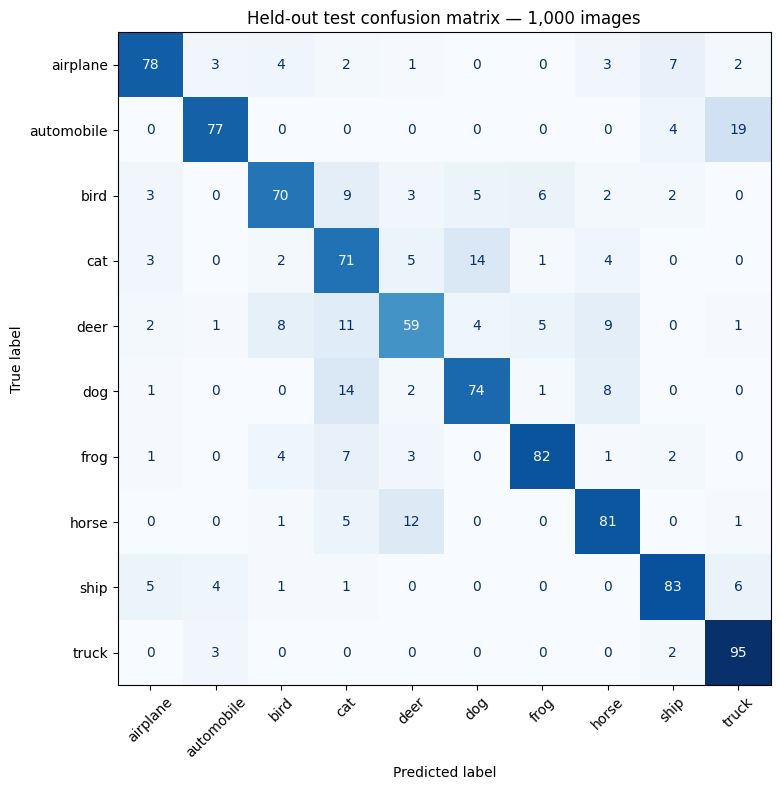

In [7]:
test_probabilities = model.predict(test_dataset, verbose=0)
assert test_probabilities.shape == (len(y_test), NUM_CLASSES)
assert np.isfinite(test_probabilities).all()
np.testing.assert_allclose(test_probabilities.sum(axis=1), 1.0, atol=1e-5)
predicted_labels = test_probabilities.argmax(axis=1)
majority_label = int(np.bincount(y_train, minlength=NUM_CLASSES).argmax())
metrics = {
    "mode": MODE, "training_images": len(y_train),
    "validation_images": len(y_validation), "test_images": len(y_test),
    "epochs_completed": len(history.history["loss"]), "selected_epoch": best_epoch,
    "test_accuracy": float(accuracy_score(y_test, predicted_labels)),
    "test_macro_f1": float(f1_score(y_test, predicted_labels, average="macro", zero_division=0)),
    "majority_baseline_accuracy": float(accuracy_score(y_test, np.full_like(y_test, majority_label))),
    "training_seconds": training_seconds,
}
print(json.dumps(metrics, indent=2))
report = classification_report(
    y_test, predicted_labels, labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES, digits=3, zero_division=0,
)
print(report)
(RUN_DIR / "classification_report.txt").write_text(report, encoding="utf-8")
np.savez_compressed(
    RUN_DIR / "test_predictions.npz", official_test_indices=test_indices,
    labels=y_test, probabilities=test_probabilities,
)
matrix = confusion_matrix(y_test, predicted_labels, labels=np.arange(NUM_CLASSES))
figure, axis = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES).plot(
    ax=axis, cmap="Blues", colorbar=False, xticks_rotation=45,
)
axis.set_title(f"Held-out test confusion matrix — {len(y_test):,} images")
figure.tight_layout()
figure.savefig(RUN_DIR / "confusion_matrix.png", dpi=140)
plt.show()

## 8. Inspect errors after evaluation

These examples describe the completed run. Further model development based
on test errors would require a new independent evaluation. Softmax scores
are not calibrated probabilities of being correct.

Misclassified: 230 of 1000 test images
automobile → truck: 19
dog → cat: 14
cat → dog: 14


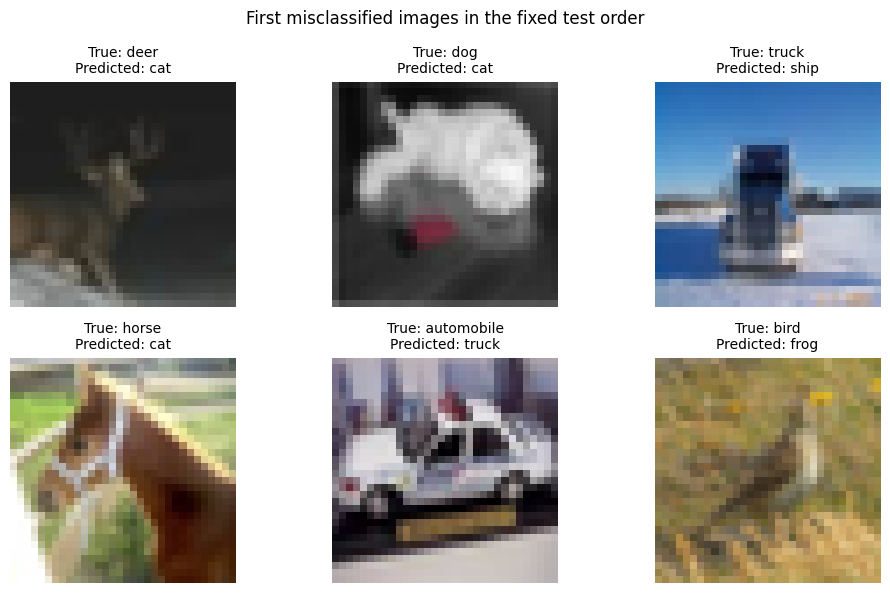

In [8]:
errors = np.flatnonzero(predicted_labels != y_test)
print(f"Misclassified: {len(errors)} of {len(y_test)} test images")
confusion_pairs = matrix.copy()
np.fill_diagonal(confusion_pairs, 0)
for index in np.argsort(confusion_pairs.ravel())[::-1][:3]:
    true_label, predicted_label = np.unravel_index(index, confusion_pairs.shape)
    count = int(confusion_pairs[true_label, predicted_label])
    if count:
        print(f"{CLASS_NAMES[true_label]} → {CLASS_NAMES[predicted_label]}: {count}")
if len(errors):
    figure, axes = plt.subplots(2, 3, figsize=(10, 6))
    for axis in axes.flat:
        axis.axis("off")
    for axis, index in zip(axes.flat, errors[:6]):
        axis.imshow(x_test[index])
        axis.set_title(
            f"True: {CLASS_NAMES[y_test[index]]}\n"
            f"Predicted: {CLASS_NAMES[predicted_labels[index]]}", fontsize=10,
        )
    figure.suptitle("First misclassified images in the fixed test order")
    figure.tight_layout()
    figure.savefig(RUN_DIR / "error_examples.png", dpi=140)
    plt.show()

## 9. Verify checkpoint reload and image-file prediction

This checks that serialization preserves predictions, including preprocessing.
The example image is from the already evaluated test partition; it is an
inference demonstration, not additional independent evidence.

In [9]:
reloaded_model = keras.models.load_model(CHECKPOINT, compile=False, safe_mode=True)
reloaded_probabilities = reloaded_model(x_test[:8], training=False).numpy()
np.testing.assert_allclose(reloaded_probabilities, test_probabilities[:8], rtol=1e-5, atol=1e-6)
print("Checkpoint reload: predictions agree for eight held-out images.")

def predict_image(image_path):
    """Predict an RGB image using saved preprocessing and classification."""
    with Image.open(image_path) as image:
        pixels = np.asarray(image.convert("RGB"), dtype=np.float32)
    scores = reloaded_model(pixels[None, ...], training=False).numpy()[0]
    class_index = int(np.argmax(scores))
    return {"class": CLASS_NAMES[class_index], "softmax_score": float(scores[class_index])}

example_path = RUN_DIR / "example_test_image.png"
Image.fromarray(x_test[0]).save(example_path)
image_prediction = predict_image(example_path)
assert image_prediction["class"] == CLASS_NAMES[predicted_labels[0]]
print("Image-file inference:", image_prediction)
print("Actual class:", CLASS_NAMES[y_test[0]])

Checkpoint reload: predictions agree for eight held-out images.
Image-file inference: {'class': 'cat', 'softmax_score': 0.46889811754226685}
Actual class: deer


## 10. Save the experiment record

Keep the checkpoint, class mapping, split indices, configuration, and
evaluation outputs together when sharing a trained model.

In [10]:
checkpoint_hash = hashlib.sha256(CHECKPOINT.read_bytes()).hexdigest()
metrics["checkpoint_reload_passed"] = True
metrics["image_file_inference_passed"] = True
metrics["total_seconds"] = time.perf_counter() - start_time
configuration = {
    "dataset": "CIFAR-10", "mode": MODE, "seed": SEED,
    "backbone": "MobileNetV2", "weights": "imagenet", "backbone_trainable": False,
    "image_size": IMAGE_SIZE, "batch_size": BATCH_SIZE, "epoch_limit": EPOCHS,
    "checkpoint_selection": "minimum validation cross-entropy loss",
    "class_names": CLASS_NAMES, "model_input": "RGB pixels in [0, 255]",
    "split_indices_sha256": split_digest, "checkpoint_sha256": checkpoint_hash,
    "environment": environment,
}
for filename, value in [("metrics.json", metrics), ("configuration.json", configuration)]:
    (RUN_DIR / filename).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n", encoding="utf-8")
(RUN_DIR / "class_names.json").write_text(json.dumps(CLASS_NAMES, indent=2) + "\n", encoding="utf-8")
print("Saved checkpoint, configuration, class names, split indices, training history,")
print("test predictions, classification report, metrics, and evaluation figures.")
print("Directory:", RUN_DIR.relative_to(ROOT))

Saved checkpoint, configuration, class names, split indices, training history,
test predictions, classification report, metrics, and evaluation figures.
Directory: runs/20260927T143525Z-17d288eb


## Interpretation and limits

- The recorded experiment trains a classification head on a CIFAR-10 subset
  using frozen ImageNet features. Full-dataset training and backbone
  fine-tuning are not established by these results.
- Resizing does not add detail to the original 32 × 32 pixels.
- Fixed seeds and saved splits support repeatability; hardware and library
  changes may still affect timing and exact numerical results.
- The checked workflow uses a CPU. Full mode and GPU execution require their
  own runtime and result checks.
- A folder-based custom dataset requires a different loader, class mapping,
  and independent splits. That workflow is not implemented here.

## References

- [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html)
- [MobileNetV2 paper](https://arxiv.org/abs/1801.04381)
- [TensorFlow transfer-learning guide](https://www.tensorflow.org/tutorials/images/transfer_learning)
- [Keras MobileNetV2 API](https://keras.io/api/applications/mobilenet/)